# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [2]:
import pandas as pd

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [8]:
df = pd.read_csv("/content/drive/MyDrive/Linguagens de programacao/datasets/vendas_brasil_aula1.csv",parse_dates=['Data_Venda'])
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?
  

> Dica: use `shape`, `columns` e `info()`.

### Resposta

In [9]:

df.shape

(300, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data_Venda      300 non-null    datetime64[ns]
 1   Canal_Venda     293 non-null    object        
 2   UF              294 non-null    object        
 3   Produto         300 non-null    object        
 4   Preco_Unitario  295 non-null    float64       
 5   Quantidade      300 non-null    int64         
 6   Custo_Unitario  300 non-null    float64       
 7   Receita         300 non-null    float64       
 8   Lucro           300 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 21.2+ KB


In [12]:
df.columns

Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')

## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

### Resposta

In [14]:
df.isnull().sum().sort_values(ascending=False)

,0
Canal_Venda,7
UF,6
Preco_Unitario,5
Data_Venda,0
Produto,0
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


In [20]:
colunas_categoricas=df.select_dtypes(include='object').columns
for col in colunas_categoricas:
  print(df[col].value_counts())
  print('\n')
  print('\n')


Canal_Venda
Loja Física    99
E-commerce     97
Marketplace    42
WhatsApp       37
e-commerce     10
loja fisica     8
Name: count, dtype: int64




UF
SP    62
RJ    43
MG    39
PR    25
BA    25
ES    23
SC    23
RS    23
PE    18
GO    13
Name: count, dtype: int64




Produto
Fone Bluetooth      52
Smartphone          42
Notebook            38
Smartwatch          37
Teclado Mecânico    37
Mouse Gamer         35
Tablet              31
Monitor             28
Name: count, dtype: int64






Coluna: Canal_venda tem  a categoria loja física, e-commerce repetidas


In [24]:
df['Canal_Venda']=df['Canal_Venda'].str.replace('loja fisica','Loja Física')
df['Canal_Venda']=df['Canal_Venda'].str.replace('e-commerce','E-commerce')

In [25]:
df['Canal_Venda'].value_counts()

,count
Canal_Venda,
Loja Física,107
E-commerce,107
Marketplace,42
WhatsApp,37


In [26]:
df.dropna(inplace=True)

## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [27]:
# Sua resposta aqui
receita_total =df['Receita'].sum()
lucro_total =df['Lucro'].sum()
ticket_medio = df['Receita'].mean()
quantidade_total_vendida = df['Quantidade'].sum()

print(f'Receita total: {receita_total}')
print(f'Lucro total: {lucro_total}')
print(f'Ticket média: {ticket_medio}')
print(f'Quantidade total de itens vendidos: {quantidade_total_vendida}')


Receita total: 640299.86
Lucro total: 172414.98
Ticket média: 2270.566879432624
Quantidade total de itens vendidos: 474


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
R: E-commerce
2. **Qual produto gera mais lucro?**
R: Notebook
3. **Quais UFs concentram maior receita?**
R: SP, MG e RJ.

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

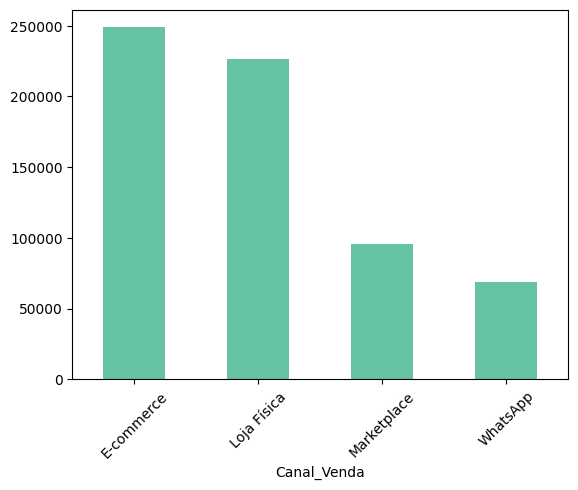

In [41]:
# Sua resposta aqui
import matplotlib.pyplot as plt
from cycler import cycler
minhas_cores= plt.get_cmap('Set2').colors
meu_ciclo = cycler('color',minhas_cores)
plt.rc('axes',prop_cycle=meu_ciclo)

df.groupby('Canal_Venda')['Receita'].sum().plot.bar()
plt.xticks(rotation=45)

plt.show()

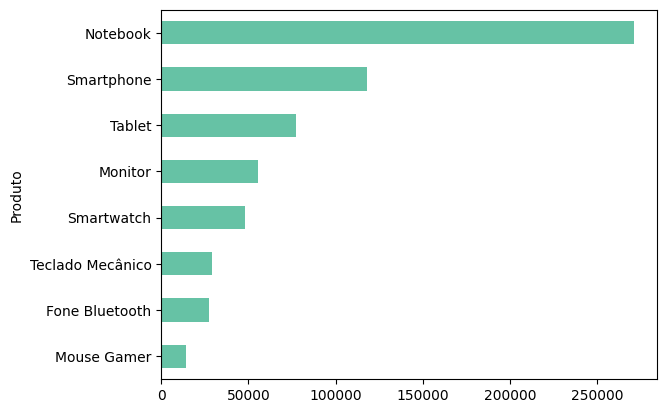

In [42]:
df.groupby('Produto')['Receita'].sum().sort_values().plot.barh()


plt.show()

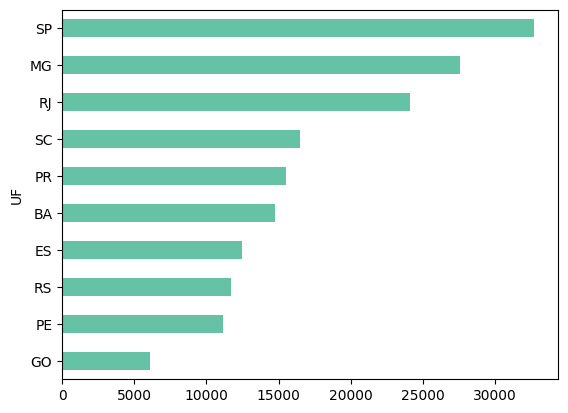

In [43]:
df.groupby('UF')['Lucro'].sum().sort_values().plot.barh()


plt.show()

## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
R: Gráfico de inhas
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?
R: Gráfico de barras  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?
R: Boxplot ou Histograma

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

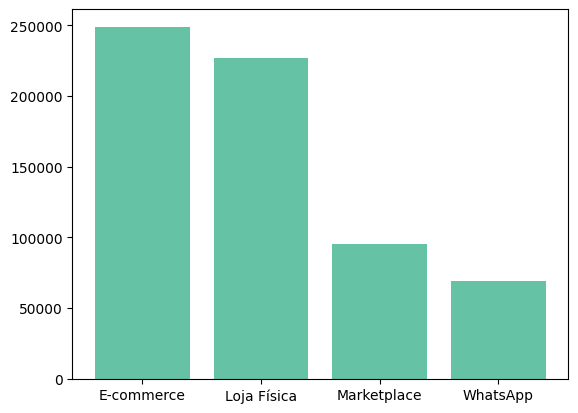

In [50]:
# Sua resposta aqui
df['Mes'] = df['Data_Venda'].dt.month_name()

df_gb_receita=df.groupby('Canal_Venda',as_index=False)['Receita'].sum()
plt.bar(df_gb_receita['Canal_Venda'],df_gb_receita['Receita'])
plt.show()

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [ ]:
# Sua resposta aqui
# Ja foi feito

## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**

R: Porque muitas vezes as bases de dados não vem adequada para análise, e com isso faz-se necessario um tratamento, além de tambem ter que entender a base de dados e entender qual o objetivo